Импорты:

In [ ]:
import numpy as np
import ollama
import pandas as pd
import re
import time

from datetime import datetime
from ollama import Client

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

1) Входящий csv файл (4_1_3.csv) лежит в папке data_input.
2) Запускаем парсинг этого файла (extract_csv.py), получаем data.csv в папке data_processed 

In [1]:
%run extract_csv.py data_input/4_1_3.csv data_processed/data.csv

Используемый разделитель: ';'
Заголовок: ['task_id', 'subject', 'grade', 'option', 'task', 'student_id', 'answer']
Прочитано строк: 200
Колонки DataFrame: ['task_id', 'subject', 'grade', 'option', 'task', 'student_id', 'answer']
Первые строки parsed (пример):
   automaticScore  totalScore  teacherScore  \
0               1           1            -1   
1               0           0            -1   
2               1           1            -1   
3               1           1            -1   
4               1           1            -1   

                                            question  \
0  Из Егорьевска в Коломну можно проехать двумя с...   
1  Из Егорьевска в Коломну можно проехать двумя с...   
2  Из Егорьевска в Коломну можно проехать двумя с...   
3  Из Егорьевска в Коломну можно проехать двумя с...   
4  Из Егорьевска в Коломну можно проехать двумя с...   

                                     correctAnswer_1  \
0  1) 19 + 20 + 18 = 57 км – длина первого пути2)...   
1  1) 19

3) В ручную размечаем data.csv и получаем data_marked.csv (в папке data_processed)
Добавляются 3 колонки H_1 H_2  (разметка первого и второго поля) H_C (разметка итоговый балл)

4) Для ускорения общего инференса вначале проверяем ответы из поля 2  (сам правильный ответ)
Логика: Если ответ правильный то 1. Если не правильный или отсутствует то 0.
На вход датафрейм student_id correctAnswer_2 userAnswer_2 На выход uswer_id  Score_2  сохраняем в data_processed/scores_2.csv


In [ ]:
# В общем случае могут быть и текстовые ответы не только float
def normalize(val):
    if pd.isna(val):
        return ''
    s = str(val).strip()
    # Пробуем преобразовать в число
    try:
        num = float(s)
        if num.is_integer():
            return str(int(num))
        else:
            return str(num)   
    except ValueError:
        return s
df = pd.read_excel('data_processed/data_marked.xlsx') 
df_sub = df[['student_id', 'correctAnswer_2', 'userAnswer_2']].copy()

# df_sub['Score_2'] = np.where(
#     (df_sub['userAnswer_2'].notna()) & 
#     (df_sub['userAnswer_2'].astype(float) == df_sub['correctAnswer_2'].astype(float)),
#     1,
#     0
# )
df_sub['Score_2'] = np.where(
    df_sub['userAnswer_2'].notna() &
    (df_sub['userAnswer_2'].apply(normalize) == df_sub['correctAnswer_2'].apply(normalize)),
    1,
    0
)

result = df_sub[['student_id', 'Score_2']]
result.to_csv('data_processed/scores_2.csv', index=False)

# Посмотрим результат
print(result.head())

   student_id  Score_2
0       89589        1
1      164562        0
2       66987        1
3       35780        1
4      141559        1


5) Создаем папки ggufs и modelfiles (внутри файл modelfile.yandex-gpt)
6) Скачиваем gguf https://huggingface.co/yandex/YandexGPT-5-Lite-8B-instruct-GGUF/tree/main
7) пишем в файле modelfile.yandex-gpt  FROM /models/ggufs/YandexGPT-5-Lite-8B-instruct-Q4_K_M.gguf
8) docker build -t ollama-yandex .
9) docker run -d -p 11436:11434   -v $(pwd)/ggufs:/ggufs   -v $(pwd)/modelfiles:/modelfiles:ro   --name ollama-container ollama-yandex 
Без флага --gpus all - Контейнеры по умолчанию не видят железо, таким образом искомый CPU инференс
10) Протестируем

In [ ]:
client = Client(host='http://localhost:11436')

response = client.chat(
    model='yandex-gpt',
    messages=[{'role': 'user', 'content': 'Назови цифру от 1 до 9 Ответь одной цифрой без пояснений'}]
)

print(response['message']['content'])



8


In [13]:
df.head(1)

,student_id,question,correctAnswer_1,userAnswer_1,right_1,wrong_1,errors_1,correctAnswer_2,userAnswer_2,right_2,wrong_2,errors_2,automaticScore,totalScore,teacherScore,H_1,H_2,H_C
0,89589,Из Егорьевска в Коломну можно проехать двумя с...,1) 19 + 20 + 18 = 57 км – длина первого пути2)...,19+20+18=57 57-48=9,0.0,0.0,0.0,9,9.0,1.0,0.0,0.0,1,1,-1,1,1,2


In [ ]:
#df_sub = df.head(200)

In [63]:
# Точное время начала
start_time = datetime.now()
print("Старт инференса:", start_time.strftime("%H:%M:%S"))
df = pd.read_excel('data_processed/data_marked.xlsx')

# Так как порт не стандартный 11434 а 11436
client = Client(host='http://localhost:11436')

SYSTEM_PROMPT = """Ты — эксперт по математике для начальной школы. Оцени, правильный ли ответ ученика на задачу. 
Учитывай, что ответ должен содержать верное решение и правильный числовой результат. 
Если ответ ученика содержит правильное решение и правильный ответ, выведи 1. 
Если логически решение правильное но есть одна арифметическая ошибка в решении, выведи 1.
Если решение логически ошибочно или арифметических ошибок больше одной или решения вообще нет  выведи 0 
В ответе выведи только одну цифру: 1 или 0, ничего другого."""

MODEL_NAME = "yandex-gpt:latest"

def evaluate_answer(question, correct_answer, user_answer):
    """Оценивает ответ ученика с помощью модели."""
    if pd.isna(user_answer) or str(user_answer).strip() == '':
        return 0  # нет ответа

    # Формируем промпт для модели
    correct_answer += " Числовой правильный ответ 9"
    user_prompt = f"""Вопрос: {question}
Правильный ответ: {correct_answer}
Ответ ученика: {user_answer}
Оценка (только 1 или 0):"""

    # Отправляем запрос в Ollama
    try:
        response = client.chat(
            model=MODEL_NAME,
            messages=[
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user', 'content': user_prompt}
            ]
        )
        result_text = response['message']['content'].strip()
        # Пытаемся извлечь 0 или 1 из ответа
        match = re.search(r'[01]', result_text)
        if match:
            return int(match.group())
        else:
            print(f"Неожиданный ответ модели: {result_text}")
            return 0
    except Exception as e:
        print(f"Ошибка при запросе к модели: {e}")
        return 0

# Список для хранения оценок
scores = []
total = len(df)

# Проходим по всем строкам
for idx, row in df.iterrows():
    student_id = row['student_id']
    question = row['question']
    correct = row['correctAnswer_1']
    user = row['userAnswer_1']

    score = evaluate_answer(question, correct, user)
    scores.append(score)

    # Выводим прогресс (опционально)
    if (idx + 1) % 10 == 0 or idx + 1 == total:
        print(f"Обработано {idx+1} из {total}")

    # Небольшая задержка, чтобы не перегружать модель (опционально)
    time.sleep(0.1)

# Создаём итоговый датафрейм
result_df = pd.DataFrame({
    'student_id': df['student_id'],
    'Score_1': scores
})

# Сохраняем результат в Excel
result_df.to_csv('data_processed/scores_1.csv', index=False)
stop_time = datetime.now()
result_df['Score_1'].to_csv('data_processed/scores_11.csv', index=False)
print("Стоп инференса:", stop_time.strftime("%H:%M:%S"))
duration = stop_time - start_time
print("Продолжительность:", duration)
print("Готово! Файл scores_1.csv создан.")

Старт инференса: 20:10:43
Обработано 10 из 200
Обработано 20 из 200
Обработано 30 из 200
Обработано 40 из 200
Обработано 50 из 200
Обработано 60 из 200
Обработано 70 из 200
Обработано 80 из 200
Обработано 90 из 200
Обработано 100 из 200
Обработано 110 из 200
Обработано 120 из 200
Обработано 130 из 200
Обработано 140 из 200
Обработано 150 из 200
Обработано 160 из 200
Обработано 170 из 200
Обработано 180 из 200
Обработано 190 из 200
Обработано 200 из 200
Стоп инференса: 20:15:12
Продолжительность: 0:04:29.023513
Готово! Файл scores_1.csv создан.


In [64]:
# 1. Загружаем исходный файл
df = pd.read_excel('data_processed/data_marked.xlsx')
df_scores1 = pd.read_csv('data_processed/scores_1.csv')  # содержит student_id и Score_1
df_scores2 = pd.read_csv('data_processed/scores_2.csv')
# Объединяем
df = df.merge(df_scores1, on='student_id', how='left')
df = df.merge(df_scores2, on='student_id', how='left')

# Если у каких-то студентов нет Score_1 (не было в файле), заполняем 0
#df['Score_1'] = df['Score_1'].fillna(0).astype(int)

# 4. Вычисляем Score_C по правилу:
#    если Score_1 == 0, то Score_C = 0, иначе Score_C = Score_1 + Score_2
df['Score_C'] = np.where(df['Score_1'] == 0, 0, df['Score_1'] + df['Score_2'])

# 5. Сохраняем итоговый датафрейм с нужными колонками
result_columns = [
    'student_id',
    'automaticScore',
    'totalScore',
    'H_1',
    'H_2',
    'H_C',
    'Score_1',
    'Score_2',
    'Score_C'
]
# Убедимся, что все колонки есть
for col in result_columns:
    if col not in df.columns:
        print(f"Внимание: колонка {col} отсутствует в данных!")

df_result = df[result_columns].copy()
df_result.to_excel('data_processed/results.xlsx', index=False)
df_result.to_csv('data_processed/results.csv', index=False)

print("Итоговый файл results.xlsx создан.")
#print(df_result.head())

Итоговый файл results.xlsx создан.


Score_C:         MAE = 0.155, RMSE = 0.543, corr = 0.838
Score_C:         MAE = 0.090, RMSE = 0.387, corr = 0.917


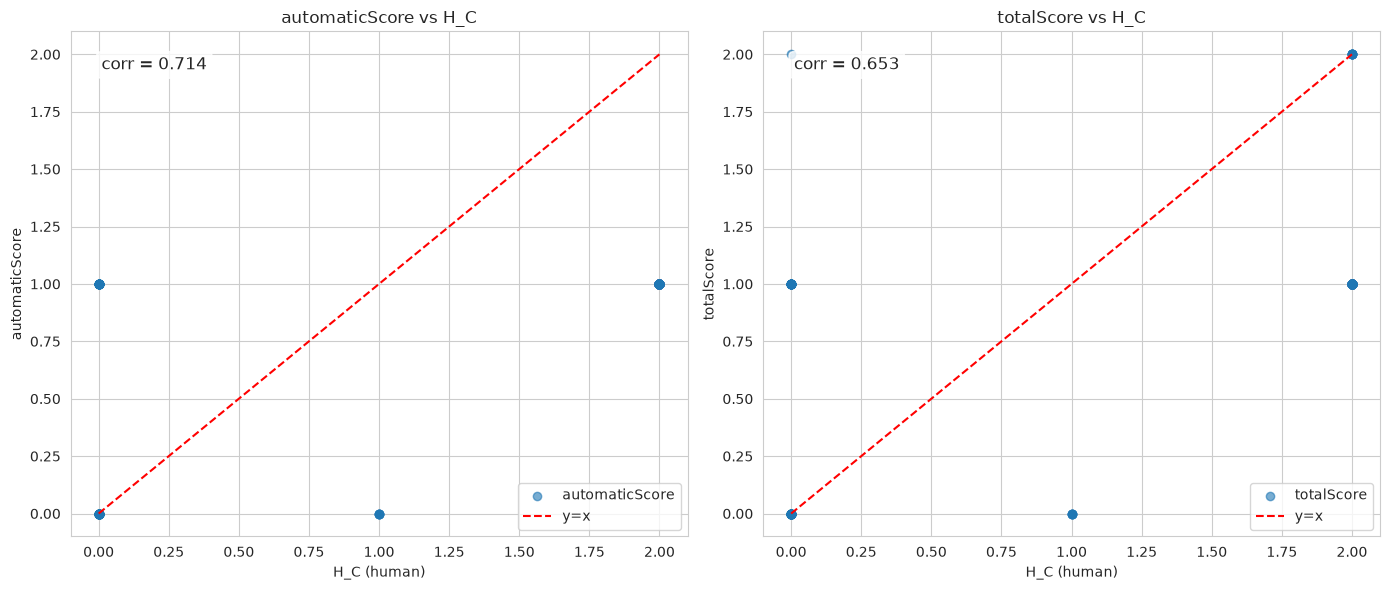

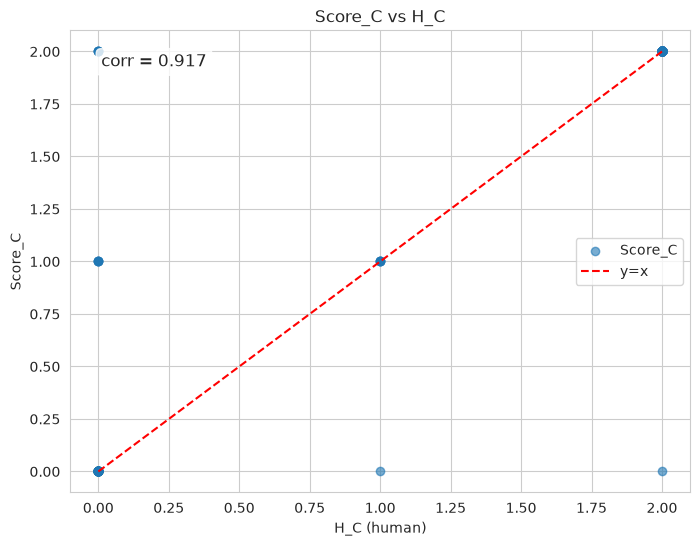


=== Статистика сравнения с H_C ===
automaticScore: MAE = 0.770, RMSE = 0.877, corr = 0.714
totalScore:      MAE = 0.735, RMSE = 0.863, corr = 0.653
Score_C:         MAE = 0.090, RMSE = 0.387, corr = 0.917


In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
# Загружаем итоговый файл
df = pd.read_excel('data_processed/results.xlsx')

# Убедимся, что все нужные колонки числовые
num_cols = ['automaticScore', 'totalScore', 'H_C', 'Score_C']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Удалим строки с NaN в H_C (если есть)
df_clean = df.dropna(subset=['H_C', 'automaticScore', 'totalScore', 'Score_C'])

# Настройка стиля
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Сравнение automaticScore и totalScore с H_C
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# automaticScore vs H_C
ax = axes[0]
ax.scatter(df_clean['H_C'], df_clean['automaticScore'], alpha=0.6, label='automaticScore')
# линия y=x
min_val = min(df_clean['H_C'].min(), df_clean['automaticScore'].min())
max_val = max(df_clean['H_C'].max(), df_clean['automaticScore'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x')
ax.set_xlabel('H_C (human)')
ax.set_ylabel('automaticScore')
ax.set_title('automaticScore vs H_C')
ax.legend()
# Корреляция
corr_auto = df_clean['automaticScore'].corr(df_clean['H_C'])
ax.text(0.05, 0.95, f'corr = {corr_auto:.3f}', transform=ax.transAxes, ha='left', va='top', fontsize=12, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# totalScore vs H_C
ax = axes[1]
ax.scatter(df_clean['H_C'], df_clean['totalScore'], alpha=0.6, label='totalScore')
ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x')
ax.set_xlabel('H_C (human)')
ax.set_ylabel('totalScore')
ax.set_title('totalScore vs H_C')
ax.legend()
corr_total = df_clean['totalScore'].corr(df_clean['H_C'])
ax.text(0.05, 0.95, f'corr = {corr_total:.3f}', transform=ax.transAxes, ha='left', va='top', fontsize=12, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# 2. Сравнение Score_C с H_C
plt.figure(figsize=(8, 6))
plt.scatter(df_clean['H_C'], df_clean['Score_C'], alpha=0.6, label='Score_C')
# линия y=x
min_val = min(df_clean['H_C'].min(), df_clean['Score_C'].min())
max_val = max(df_clean['H_C'].max(), df_clean['Score_C'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x')
plt.xlabel('H_C (human)')
plt.ylabel('Score_C')
plt.title('Score_C vs H_C')
plt.legend()
corr_score = df_clean['Score_C'].corr(df_clean['H_C'])
plt.text(0.05, 0.95, f'corr = {corr_score:.3f}', transform=plt.gca().transAxes, ha='left', va='top', fontsize=12, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.show()

# Вывод метрик
print("\n=== Статистика сравнения с H_C ===")
print(f"automaticScore: MAE = {mean_absolute_error(df_clean['H_C'], df_clean['automaticScore']):.3f}, RMSE = {np.sqrt(mean_squared_error(df_clean['H_C'], df_clean['automaticScore'])):.3f}, corr = {corr_auto:.3f}")
print(f"totalScore:      MAE = {mean_absolute_error(df_clean['H_C'], df_clean['totalScore']):.3f}, RMSE = {np.sqrt(mean_squared_error(df_clean['H_C'], df_clean['totalScore'])):.3f}, corr = {corr_total:.3f}")
print(f"Score_C:         MAE = {mean_absolute_error(df_clean['H_C'], df_clean['Score_C']):.3f}, RMSE = {np.sqrt(mean_squared_error(df_clean['H_C'], df_clean['Score_C'])):.3f}, corr = {corr_score:.3f}")


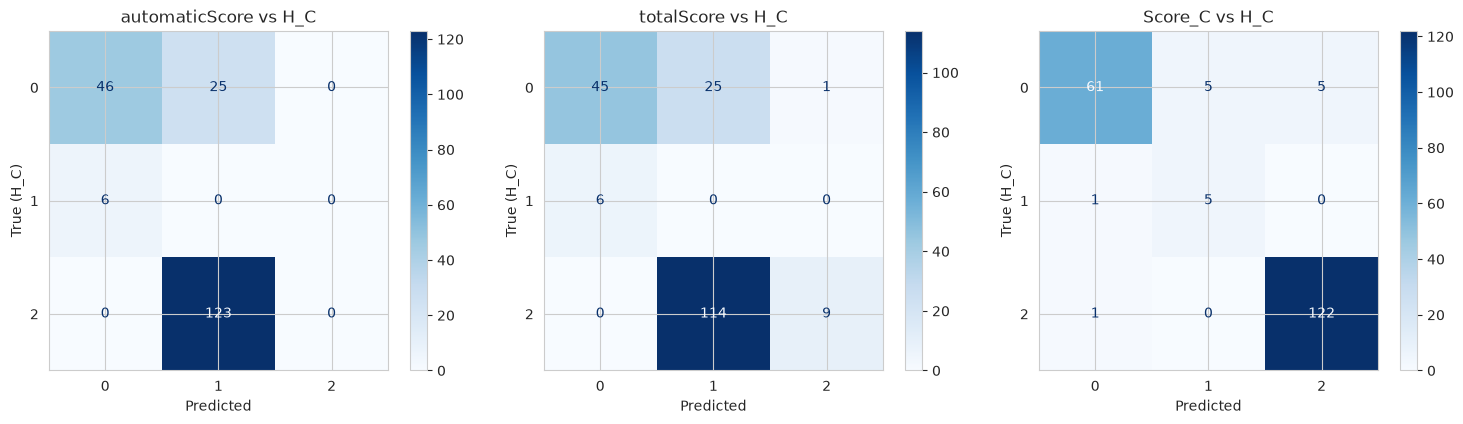

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

methods = {
    'automaticScore': df_clean['automaticScore'],
    'totalScore': df_clean['totalScore'],
    'Score_C': df_clean['Score_C']
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pred) in zip(axes, methods.items()):
    cm = confusion_matrix(df_clean['H_C'], pred, labels=[0,1,2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'{name} vs H_C')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True (H_C)')

plt.tight_layout()
plt.show()

In [70]:
# Проверяем, что в scores_1.xlsx
df_s1 = pd.read_csv('data_processed/scores_1.csv')
print("Score_1 в scores_1.xlsx:")
print(df_s1['Score_1'].value_counts())

# Проверяем итоговый файл
df_res = pd.read_excel('data_processed/results.xlsx')
print("В results.xlsx:")
print(df_res[['Score_1', 'Score_2', 'Score_C']].head(20))
print("Распределение Score_1:", df_res['Score_1'].value_counts())
print("Распределение Score_C:", df_res['Score_C'].value_counts())

Score_1 в scores_1.xlsx:
Score_1
1    137
0     63
Name: count, dtype: int64
В results.xlsx:
    Score_1  Score_2  Score_C
0         1        1        2
1         0        0        0
2         1        1        2
3         1        1        2
4         0        1        0
5         0        0        0
6         1        1        2
7         1        1        2
8         1        1        2
9         0        0        0
10        1        1        2
11        1        1        2
12        0        1        0
13        0        0        0
14        1        0        1
15        1        1        2
16        1        1        2
17        0        0        0
18        1        1        2
19        0        0        0
Распределение Score_1: Score_1
1    137
0     63
Name: count, dtype: int64
Распределение Score_C: Score_C
2    127
0     63
1     10
Name: count, dtype: int64
